Tema 9. Volume de Chuvas e Ocorrência de Deslizamentos em Cidades do RJ
Objetivo: Investigar a relação entre volume de chuvas e número de deslizamentos, identificando períodos de maior risco.
Espera-se que o notebook contenha:
• Volume mensal de chuvas por cidade.
• Quantidade de deslizamentos registrados no mesmo período.
• Indicação de correlação ou tendência.
Passos esperados no notebook:
1. Carregar dados mensais de chuva e deslizamentos por cidade.
2. Unificar os dados para cada mês/ano.
3. Visualizar séries temporais e verificar correlação.
4. Indicar meses mais críticos e sugerir ações preventivas.

## Deslizamentos e Chuvas no RJ | Linguagens de Programação
### Professor: Alexandre Louzada
### Aluna: Giovanna Poggi
---
O estado do Rio de Janeiro tem histórico de tragédias com chuva forte, principalmente na serra (Petrópolis, Teresópolis, Nova Friburgo) e nas encostas da região metropolitana. Os deslizamentos destroem casas, fecham estradas e matam pessoas inocentes.

Neste projeto, pretendo utilizar dados mensais de chuva e do número de deslizamentos das 7 cidades do estado mais afetadas por eles, a fim de encontrar e comprovar a relação entre as chuvas e os deslizamentos, buscando informações úteis para que a Defesa Civil planeje ações nos meses certos e proteja melhor a população de desastres naturais.

### 2. Definição do Problema (ESSENCIAL)
- Qual pergunta você deseja responder?
    - A partir de qual volume mensal de chuva os deslizamentos aumentam de forma relevante, e quais meses e cidades devem ser priorizados na prevenção?
- Por que essa pergunta é relevante?
    - Se existe um limiar de chuva, ele vira um gatilho objetivo de alerta. Se o risco se concentra em certos meses ou cidades, dá para planejar um calendário e distribuir as equipes.
- Qual decisão poderia ser tomada com base nessa análise?
    - Definir níveis de alerta da Defesa Civil pelo volume de chuva do mês.
    - Decidir se a prevenção segue um calendário fixo (ex.: só no verão) ou o monitoramento da chuva.
    - Escolher quais cidades recebem prioridade em obras de contenção de encostas.

---

### 3. Definição de KPI(s)

1. **KPI principal:** média de deslizamentos por faixa de chuva
   - Cálculo: agrupa os meses em faixas (0–150, 150–250, 250–400, 400+ mm)
     e calcula a média de deslizamentos por cidade-mês em cada faixa.
   - Razão: responde diretamente "a partir de quanto a chuva vira risco".
     As faixas viram os níveis de alerta.

2. **KPI de apoio 1:** correlação entre chuva e deslizamentos
   - Cálculo: correlação de Pearson entre `chuva_mm` e `deslizamentos` (vai de -1 a 1).
   - Razão: mede se as duas variáveis andam juntas e com que força.

3. **KPI de apoio 2:** deslizamentos por 100 mm de chuva
   - Cálculo: soma(deslizamentos) / soma(chuva_mm) × 100, por cidade.
   - Razão: a cidade onde chove mais naturalmente terá mais deslizamentos.
     Esse KPI mostra quais cidades são mais **sensíveis** à chuva.

**Obs.:** as faixas foram escolhidas depois da exploração (seção 6), que mostrou um limiar exato em 150 mm. Os cortes de 250 e 400 mm separam chuva moderada, forte e extrema.

---

In [1]:
import io
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# padrão visual único para todos os gráficos: fundo limpo, sem bordas de cima/direita
sns.set_theme(style="ticks")
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# cores: roxo = cor principal, laranja = destaque (faixa crítica), cinza = referência,
# ciano = nível de atenção (usado só no gráfico das faixas de alerta)
CYAN = "#2ad6b1"
ROXO = "#a52ad6"
LARANJA = "#eb6834"
CINZA = "#8a8984"

---
### 4. Aquisição dos Dados
- Fonte dos dados
- Método de obtenção (upload ou requests)
- Descrição das variáveis principais

In [2]:
# aquisição dos dados: download direto para a memória
URL = ("https://raw.githubusercontent.com/AlexandreLouzada/Dados-Simulados/"
       "main/Simulacao_Chuva_Deslizamentos_RJ_2015_2023.xlsx")

resposta = requests.get(URL, timeout=30)
resposta.raise_for_status()  # se o download falhar, para aqui com erro claro

# BytesIO: o read_excel lê o arquivo direto da memória, sem salvar no disco
df_bruto = pd.read_excel(io.BytesIO(resposta.content))
print("formato:", df_bruto.shape)
df_bruto.head()

formato: (756, 5)


,Cidade,Ano,Mês,Volume de Chuva (mm),Número de Deslizamentos
0,Petrópolis,2015,Jan,256.0,12
1,Petrópolis,2015,Fev,452.6,15
2,Petrópolis,2015,Mar,135.8,0
3,Petrópolis,2015,Abr,135.8,0
4,Petrópolis,2015,Mai,81.9,0


In [3]:
df_bruto.info()

<class 'pandas.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Cidade                   756 non-null    str    
 1   Ano                      756 non-null    int64  
 2   Mês                      756 non-null    str    
 3   Volume de Chuva (mm)     756 non-null    float64
 4   Número de Deslizamentos  756 non-null    int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 41.1 KB


**Fonte:** repositório do professor no GitHub ([Dados-Simulados](https://github.com/AlexandreLouzada/Dados-Simulados)), arquivo `Simulacao_Chuva_Deslizamentos_RJ_2015_2023.xlsx`.
**Método:** download direto com `requests` (não precisa fazer upload).
**Atenção:** os dados são **simulados**, não são registros oficiais.

| Variável | Tipo | Significado |
|---|---|---|
| Cidade | texto | uma das 7 cidades do RJ |
| Ano | inteiro | 2015 a 2023 |
| Mês | texto | Jan ... Dez |
| Volume de Chuva (mm) | decimal | chuva acumulada no mês |
| Número de Deslizamentos | inteiro | deslizamentos registrados no mês |

São 7 cidades × 9 anos × 12 meses = **756 linhas**.

---
### 5. Limpeza dos dados
- Tratamento de valores nulos
- Conversão de tipos
- Renomeação de colunas
- Criação de novas variáveis (se necessário)

In [4]:
# renomeação de colunas

# nomes sem acento, sem espaço e sem parênteses: mais fácil de digitar e evita erros

df = df_bruto.rename(columns={
    "Cidade": "cidade",
    "Ano": "ano",
    "Mês": "mes",
    "Volume de Chuva (mm)": "chuva_mm",
    "Número de Deslizamentos": "deslizamentos",
})
df.columns.tolist()

['cidade', 'ano', 'mes', 'chuva_mm', 'deslizamentos']

In [5]:
# valores nulos, duplicados e impossíveis

print("nulos por coluna:")
print(df.isna().sum())

# cada cidade só pode aparecer uma vez por mês/ano
dup = df.duplicated(subset=["cidade", "ano", "mes"]).sum()
print("\nlinhas duplicadas (cidade+ano+mes):", dup)

# chuva e deslizamento não podem ser negativos
print("chuva negativa:", (df["chuva_mm"] < 0).sum())
print("deslizamento negativo:", (df["deslizamentos"] < 0).sum())

# cada cidade deveria ter 9 anos x 12 meses = 108 registros
print("\nregistros por cidade:")
print(df["cidade"].value_counts())

nulos por coluna:
cidade           0
ano              0
mes              0
chuva_mm         0
deslizamentos    0
dtype: int64

linhas duplicadas (cidade+ano+mes): 0
chuva negativa: 0
deslizamento negativo: 0

registros por cidade:
cidade
Petrópolis         108
Teresópolis        108
Nova Friburgo      108
Niterói            108
Angra dos Reis     108
Duque de Caxias    108
Rio de Janeiro     108
Name: count, dtype: int64


In [6]:
# a base veio sem nenhum erro!
# mesmo assim, deixo a limpeza pronta: linha sem chuva ou sem deslizamento não serve para a análise

antes = len(df)
df = df.dropna(subset=["chuva_mm", "deslizamentos"]).drop_duplicates(subset=["cidade", "ano", "mes"])
print(f"linhas removidas: {antes - len(df)}")

linhas removidas: 0


In [7]:
# conversão de tipos e novas variáveis úteis

# o mês vem como texto ("Jan"), então não dá para ordenar nem montar uma data
# vamos mapear para número e depois criar uma data de verdade (dia 1 de cada mês)

MESES = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun", "Jul", "Ago", "Set", "Out", "Nov", "Dez"]
df["mes_num"] = df["mes"].map({m: i + 1 for i, m in enumerate(MESES)})

# confere se todo mês foi reconhecido (se tivesse "jan" minúsculo, viraria NaN)
assert df["mes_num"].notna().all()

df["data"] = pd.to_datetime(dict(year=df["ano"], month=df["mes_num"], day=1))

# Categorical ordenado: gráficos e groupby respeitam Jan -> Dez em vez da ordem alfabética
df["mes"] = pd.Categorical(df["mes"], categories=MESES, ordered=True)
df["cidade"] = df["cidade"].astype("category")

In [8]:
# faixas de chuva = níveis de alerta (KPI principal)
# right=False: o intervalo inclui o limite de baixo. 150 mm já cai em "Atenção"

FAIXAS = [0, 150, 250, 400, np.inf]
NIVEIS = ["Sem risco\n(< 150 mm)", "Atenção\n(150–250 mm)", "Alerta\n(250–400 mm)", "Crítico\n(≥ 400 mm)"]
df["faixa_chuva"] = pd.cut(df["chuva_mm"], bins=FAIXAS, labels=NIVEIS, right=False)

# mês com deslizamento ou não (sim/não)
df["teve_deslizamento"] = df["deslizamentos"] > 0

df.dtypes

cidade                     category
ano                           int64
mes                        category
chuva_mm                    float64
deslizamentos                 int64
mes_num                       int64
data                 datetime64[us]
faixa_chuva                category
teve_deslizamento              bool
dtype: object

In [9]:
df.head()

,cidade,ano,mes,chuva_mm,deslizamentos,mes_num,data,faixa_chuva,teve_deslizamento
0,Petrópolis,2015,Jan,256.0,12,1,2015-01-01,Alerta\n(250–400 mm),True
1,Petrópolis,2015,Fev,452.6,15,2,2015-02-01,Crítico\n(≥ 400 mm),True
2,Petrópolis,2015,Mar,135.8,0,3,2015-03-01,Sem risco\n(< 150 mm),False
3,Petrópolis,2015,Abr,135.8,0,4,2015-04-01,Sem risco\n(< 150 mm),False
4,Petrópolis,2015,Mai,81.9,0,5,2015-05-01,Sem risco\n(< 150 mm),False


---
### 5.1 Persistência em banco (SQLAlchemy + SQLite)
A base tratada é gravada numa tabela `chuvas` dentro de `database/chuvas_deslizamentos.sqlite`.
Assim o dashboard e outras análises podem consultar os dados com SQL, sem repetir a limpeza.

In [10]:
from pathlib import Path
from sqlalchemy import create_engine, text

# o notebook fica em notebooks/, então o banco fica uma pasta acima, em database/
CAMINHO_BANCO = Path("..") / "database" / "chuvas_deslizamentos.sqlite"
CAMINHO_BANCO.parent.mkdir(exist_ok=True)
engine = create_engine(f"sqlite:///{CAMINHO_BANCO}")

# sqlite não tem tipo category nem datetime: mês e faixa vão como texto
tabela = df[["cidade", "ano", "mes", "mes_num", "chuva_mm", "deslizamentos", "faixa_chuva"]].astype(
    {"cidade": str, "mes": str, "faixa_chuva": str}
)
tabela["faixa_chuva"] = tabela["faixa_chuva"].str.replace("\n", " ")
tabela.to_sql("chuvas", engine, if_exists="replace", index=False)

# confere se tudo foi gravado
with engine.connect() as conn:
    print("linhas no banco:", conn.execute(text("SELECT COUNT(*) FROM chuvas")).scalar())

linhas no banco: 756


In [11]:
# consulta sql: total de deslizamentos e chuva média por cidade, direto no banco
consulta = """
SELECT cidade,
       SUM(deslizamentos)       AS total_desliz,
       ROUND(AVG(chuva_mm), 1)  AS chuva_media
FROM chuvas
GROUP BY cidade
ORDER BY total_desliz DESC
"""
pd.read_sql(consulta, engine)

,cidade,total_desliz,chuva_media
0,Nova Friburgo,1088,356.4
1,Duque de Caxias,1054,340.5
2,Petrópolis,943,320.8
3,Rio de Janeiro,922,329.1
4,Teresópolis,878,294.8
5,Angra dos Reis,872,322.4
6,Niterói,816,315.7


---

### 6. Análise Exploratória

In [12]:
print(df[["chuva_mm", "deslizamentos"]].describe().round(1))

print(f"meses sem nenhum deslizamento: {(~df['teve_deslizamento']).sum()} de {len(df)} "
      f"({(~df['teve_deslizamento']).mean():.1%})")

       chuva_mm  deslizamentos
count     756.0          756.0
mean      325.7            8.7
std       166.3            7.2
min        52.5            0.0
25%       173.4            3.0
50%       330.3            8.0
75%       476.7           13.0
max       599.8           29.0
meses sem nenhum deslizamento: 158 de 756 (20.9%)


**O que os números mostram:**
- a chuva mensal vai de 52 a 600 mm, com média de ~326 mm.
- os deslizamentos vão de 0 a 29 por mês, com média de ~8,7.
- 1 em cada 5 meses não teve nenhum deslizamento.

Próxima pergunta: o que esses meses sem deslizamento têm em comum?

In [13]:
sem = df[~df["teve_deslizamento"]]
com = df[df["teve_deslizamento"]]

print(f"meses SEM deslizamento -> chuva máxima: {sem['chuva_mm'].max():.1f} mm")
print(f"meses COM deslizamento -> chuva mínima: {com['chuva_mm'].min():.1f} mm")

meses SEM deslizamento -> chuva máxima: 149.9 mm
meses COM deslizamento -> chuva mínima: 150.1 mm


In [14]:
# lupa em volta do limiar: faixas de 10 em 10 mm entre 100 e 250
zoom = df[df["chuva_mm"].between(100, 250, inclusive="left")].copy()
zoom["faixa_10mm"] = (zoom["chuva_mm"] // 10 * 10).astype(int)

zoom.groupby("faixa_10mm").agg(
    meses=("deslizamentos", "size"),
    media_desliz=("deslizamentos", "mean"),
    pct_com_desliz=("teve_deslizamento", "mean"),
).round(2)

,meses,media_desliz,pct_com_desliz
faixa_10mm,,,
100,20,0.00,0.0
110,15,0.00,0.0
120,17,0.00,0.0
130,15,0.00,0.0
140,16,0.00,0.0
150,15,3.33,1.0
160,8,2.62,1.0
170,14,4.79,1.0
180,20,4.70,1.0


**Achado-chave: a separação é perfeita!**

Nenhum mês abaixo de 150 mm de chuva teve deslizamento.
**Todo** mês a partir de 150 mm teve deslizamento.

### 150 mm é o nosso primeiro corte de alerta.
---

### KPI principal: deslizamentos por faixa de chuva

In [15]:
kpi_faixa = df.groupby("faixa_chuva", observed=True).agg(
    meses=("deslizamentos", "size"),
    media_desliz=("deslizamentos", "mean"),
    total_desliz=("deslizamentos", "sum"),
)
kpi_faixa["pct_meses"] = kpi_faixa["meses"] / kpi_faixa["meses"].sum() * 100
kpi_faixa["pct_desliz"] = kpi_faixa["total_desliz"] / kpi_faixa["total_desliz"].sum() * 100

kpi_faixa.rename(index=lambda s: s.replace("\n", " ")).round(1)

,meses,media_desliz,total_desliz,pct_meses,pct_desliz
faixa_chuva,,,,,
Sem risco (< 150 mm),158,0.0,0,20.9,0.0
Atenção (150–250 mm),135,5.4,725,17.9,11.0
Alerta (250–400 mm),172,9.2,1591,22.8,24.2
Crítico (≥ 400 mm),291,14.6,4257,38.5,64.8


**Leitura do KPI:** o risco sobe em degraus — 0 → 5,4 → 9,2 → 14,6 deslizamentos por mês.
Os meses críticos (≥ 400 mm) são 38,5% dos meses, mas concentram **65% de todos os deslizamentos**.
Um mês crítico tem quase 3× mais deslizamentos que um mês de atenção.

---

### KPI de apoio 1: correlação entre chuva e deslizamentos

In [16]:
# correlação: número de -1 a 1. perto de 1 = quando uma sobe, a outra também sobe
print("correlação geral:", round(df["chuva_mm"].corr(df["deslizamentos"]), 2))

# a relação vale em todas as cidades?
print("\ncorrelação por cidade:")
for cidade, dados in df.groupby("cidade", observed=True):
    print(f"  {cidade}: {dados['chuva_mm'].corr(dados['deslizamentos']):.2f}")

correlação geral: 0.81

correlação por cidade:
  Angra dos Reis: 0.81
  Duque de Caxias: 0.81
  Niterói: 0.78
  Nova Friburgo: 0.80
  Petrópolis: 0.83
  Rio de Janeiro: 0.82
  Teresópolis: 0.84


A correlação geral é **0,81** (forte e positiva) e aparece em **todas** as 7 cidades (de 0,78 a 0,84).
Ou seja: não é efeito de uma cidade só, a relação chuva → deslizamento vale para o estado todo.

---

### KPI de apoio 2: comparação entre cidades

In [17]:
por_cidade = df.groupby("cidade", observed=True).agg(
    chuva_media=("chuva_mm", "mean"),
    chuva_total=("chuva_mm", "sum"),
    desliz_total=("deslizamentos", "sum"),
)

# quantos deslizamentos a cidade tem a cada 100 mm de chuva (sensibilidade)
por_cidade["desliz_por_100mm"] = por_cidade["desliz_total"] / por_cidade["chuva_total"] * 100

por_cidade.sort_values("desliz_por_100mm", ascending=False).round(2)

,chuva_media,chuva_total,desliz_total,desliz_por_100mm
cidade,,,,
Duque de Caxias,340.49,36772.4,1054,2.87
Nova Friburgo,356.36,38486.5,1088,2.83
Teresópolis,294.85,31843.6,878,2.76
Petrópolis,320.82,34648.5,943,2.72
Rio de Janeiro,329.11,35544.2,922,2.59
Angra dos Reis,322.43,34822.7,872,2.50
Niterói,315.71,34096.9,816,2.39


**Duque de Caxias** e **Nova Friburgo** lideram tanto no total de deslizamentos quanto na sensibilidade (~2,9 por 100 mm).
**Niterói** é a menos sensível (2,4). A diferença entre a mais e a menos sensível é de ~20%: existe, mas é moderada.

---

### Sazonalidade: existem meses do ano mais perigosos?

In [18]:
por_mes = df.groupby("mes", observed=True).agg(
    chuva_media=("chuva_mm", "mean"),
    desliz_medio=("deslizamentos", "mean"),
)
por_mes.round(1)

,chuva_media,desliz_medio
mes,,
Jan,337.4,9.5
Fev,360.9,9.2
Mar,295.2,8.1
Abr,334.1,8.9
Mai,305.6,8.1
Jun,318.3,8.9
Jul,328.5,8.3
Ago,343.6,9.2
Set,340.2,9.1


Dez, Jan, Fev, Abr, Jun, Ago e Set ficam um pouco acima da média (8,7); Out e Nov são os mais baixos.
Mas entre o pior mês (Dez, 9,7) e o melhor (Nov, 7,4) a diferença é de só **~2,3 deslizamentos**,
enquanto entre as faixas de chuva a diferença chega a **14,6**.

-> **O volume de chuva explica muito mais do que o mês do ano.**

---

### Os 10 piores episódios

In [19]:
df.nlargest(10, "deslizamentos")[["cidade", "ano", "mes", "chuva_mm", "deslizamentos"]]

,cidade,ano,mes,chuva_mm,deslizamentos
299,Nova Friburgo,2021,Dez,599.8,29
76,Petrópolis,2021,Mai,584.5,28
136,Teresópolis,2017,Mai,581.7,28
252,Nova Friburgo,2018,Jan,571.0,28
281,Nova Friburgo,2020,Jun,585.9,28
19,Petrópolis,2016,Ago,571.9,27
132,Teresópolis,2017,Jan,567.3,27
571,Duque de Caxias,2017,Ago,558.4,27
615,Duque de Caxias,2021,Abr,560.3,27
451,Angra dos Reis,2016,Ago,563.9,26


Os 10 piores episódios tiveram **todos mais de 550 mm** de chuva, e aconteceram em meses variados
(Jan, Abr, Mai, Jun, Ago, Dez). De novo: o que une os piores casos é a chuva extrema, não a época do ano.

---

### 7. Visualizações
Cada gráfico abaixo responde uma parte da pergunta do projeto.

#### 7.1 Chuva x deslizamentos (dispersão)

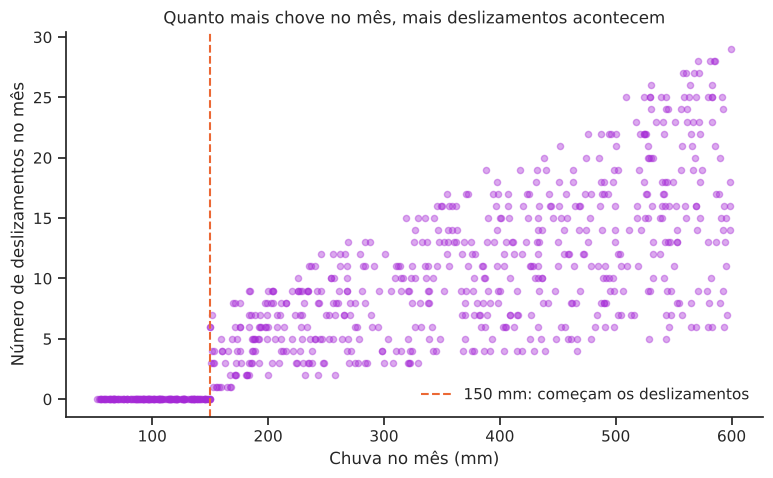

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.scatter(df["chuva_mm"], df["deslizamentos"], color=ROXO, alpha=0.4, s=20)
ax.axvline(150, color=LARANJA, linestyle="--", label="150 mm: começam os deslizamentos")

ax.set_title("Quanto mais chove no mês, mais deslizamentos acontecem")
ax.set_xlabel("Chuva no mês (mm)")
ax.set_ylabel("Número de deslizamentos no mês")
ax.legend(frameon=False)
plt.show()

Cada ponto é uma cidade em um mês. À esquerda da linha tracejada tudo é zero; à direita, os pontos sobem de forma consistente.
A relação é forte, mas não exata: com ~400 mm um mês pode ter de 8 a 20 deslizamentos.
Isso mostra que outros fatores (tipo de solo, ocupação das encostas, chuva concentrada em poucos dias) também pesam.

#### 7.2 KPI principal: média de deslizamentos por nível de alerta (barras)

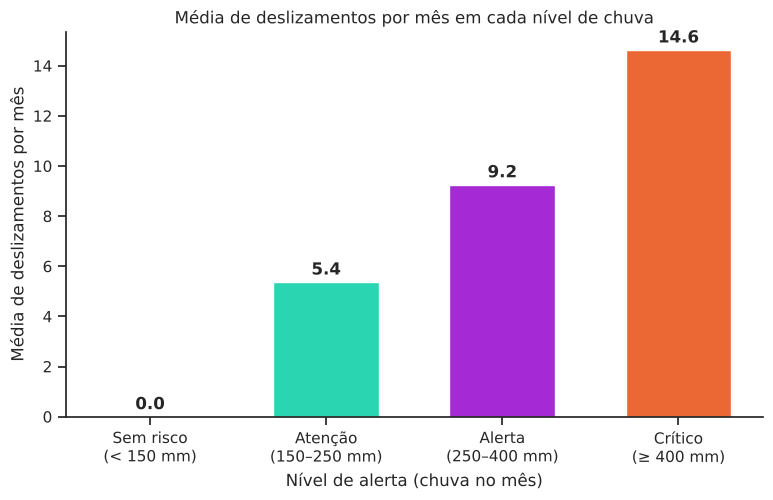

In [21]:
fig, ax = plt.subplots(figsize=(9, 5))

# uma cor para cada nível de alerta: cinza (sem risco), ciano (atenção), roxo (alerta), laranja (crítico)
cores = [CINZA, CYAN, ROXO, LARANJA]
ax.bar(kpi_faixa.index.astype(str), kpi_faixa["media_desliz"], color=cores, width=0.6)

# escreve o valor em cima de cada barra
for i, valor in enumerate(kpi_faixa["media_desliz"]):
    ax.text(i, valor + 0.3, f"{valor:.1f}", ha="center", fontweight="bold")

ax.set_title("Média de deslizamentos por mês em cada nível de chuva")
ax.set_xlabel("Nível de alerta (chuva no mês)")
ax.set_ylabel("Média de deslizamentos por mês")
plt.show()

O risco sobe em degraus bem claros: **zero** abaixo de 150 mm, ~5 em atenção, ~9 em alerta e ~15 no crítico.
Essas faixas podem virar diretamente os níveis de alerta da Defesa Civil.

#### 7.3 Com que frequência a chuva passa dos limites? (histograma)

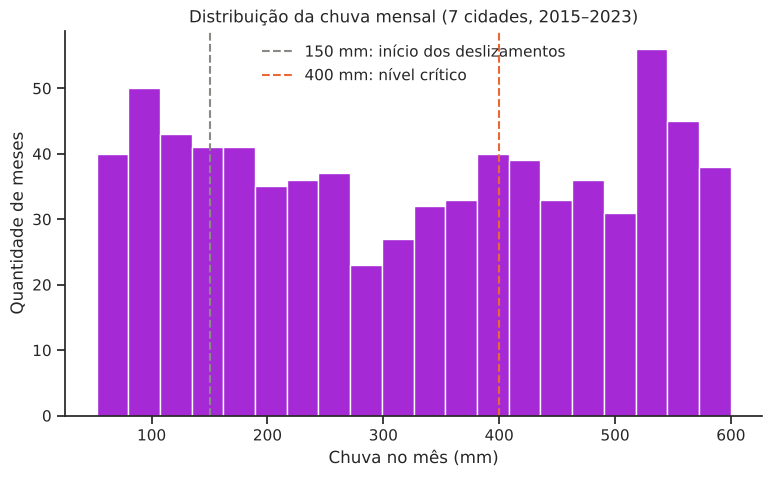

In [22]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(df["chuva_mm"], bins=20, color=ROXO, edgecolor="white")
ax.axvline(150, color=CINZA, linestyle="--", label="150 mm: início dos deslizamentos")
ax.axvline(400, color=LARANJA, linestyle="--", label="400 mm: nível crítico")

ax.set_title("Distribuição da chuva mensal (7 cidades, 2015–2023)")
ax.set_xlabel("Chuva no mês (mm)")
ax.set_ylabel("Quantidade de meses")
ax.legend(frameon=False)
plt.show()

A chuva é bem espalhada entre 150 e 600 mm, não existe um "valor típico".
Na prática, **4 em cada 5 meses** passam do limite de 150 mm e **quase 4 em cada 10** chegam ao nível crítico.
O risco é recorrente, não é raro.

#### 7.4 Chuva e deslizamentos ao longo do tempo (linhas)

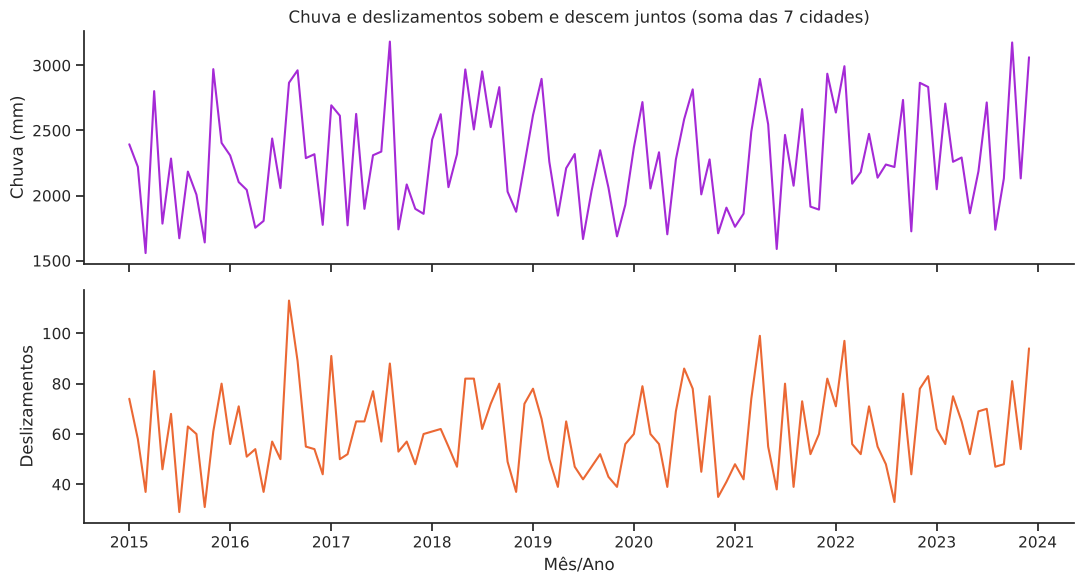

In [23]:
# soma das 7 cidades em cada mês = visão do estado inteiro
serie = df.groupby("data")[["chuva_mm", "deslizamentos"]].sum()

# dois gráficos, um em cima do outro, com o mesmo eixo de tempo
# (chuva e deslizamento têm escalas muito diferentes, não cabem no mesmo eixo y)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

ax1.plot(serie.index, serie["chuva_mm"], color=ROXO)
ax1.set_title("Chuva e deslizamentos sobem e descem juntos (soma das 7 cidades)")
ax1.set_ylabel("Chuva (mm)")

ax2.plot(serie.index, serie["deslizamentos"], color=LARANJA)
ax2.set_ylabel("Deslizamentos")
ax2.set_xlabel("Mês/Ano")

plt.tight_layout()
plt.show()

Os picos de chuva batem com os picos de deslizamento praticamente mês a mês.
Não há tendência de crescimento ao longo dos anos (o total anual fica entre ~620 e ~770),
e também não aparece uma "onda" repetida todo verão — o que confirma o resultado da sazonalidade.

#### 7.5 Média de deslizamentos por mês do ano (barras)

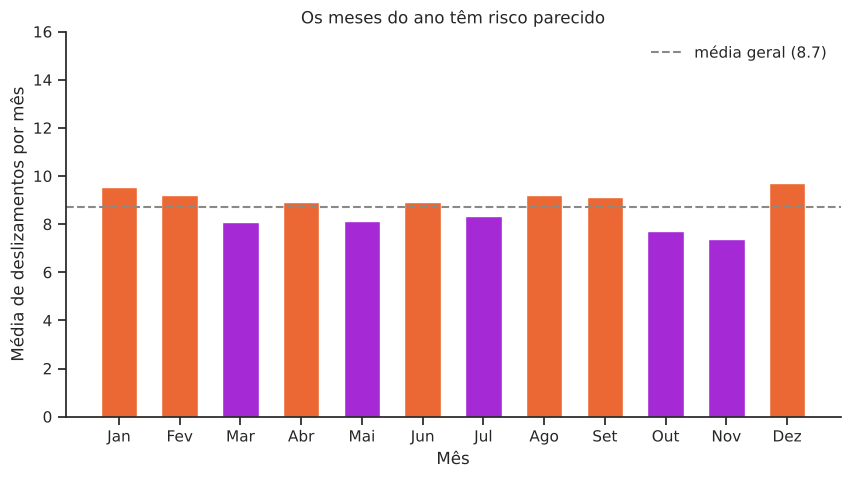

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))

media_geral = df["deslizamentos"].mean()
# laranja = mês acima da média geral
cores_mes = [LARANJA if v > media_geral else ROXO for v in por_mes["desliz_medio"]]

ax.bar(por_mes.index.astype(str), por_mes["desliz_medio"], color=cores_mes, width=0.6)
ax.axhline(media_geral, color=CINZA, linestyle="--", label=f"média geral ({media_geral:.1f})")

ax.set_title("Os meses do ano têm risco parecido")
ax.set_xlabel("Mês")
ax.set_ylabel("Média de deslizamentos por mês")
ax.set_ylim(0, 16)  # mesma escala do gráfico 7.2, para comparar
ax.legend(frameon=False)
plt.show()

Usando a **mesma escala** do gráfico 7.2 fica clara a diferença: lá as barras vão de 0 a 15, aqui ficam todas entre 7 e 10.
Os meses acima da média (laranja) não seguem o padrão "verão chuvoso / inverno seco" — Ago e Set também aparecem.
Planejar a prevenção **só pelo calendário** deixaria meses de risco descobertos.

#### 7.6 Quais cidades são mais sensíveis à chuva? (barras horizontais)

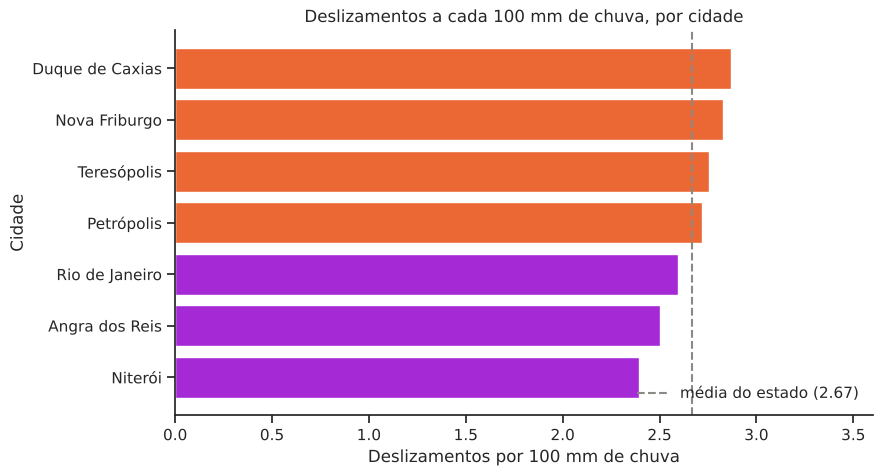

In [25]:
ordem = por_cidade.sort_values("desliz_por_100mm")  # menor embaixo, maior em cima
media_estado = df["deslizamentos"].sum() / df["chuva_mm"].sum() * 100

fig, ax = plt.subplots(figsize=(9, 5))

cores_cid = [LARANJA if v > media_estado else ROXO for v in ordem["desliz_por_100mm"]]
ax.barh(ordem.index.astype(str), ordem["desliz_por_100mm"], color=cores_cid)
ax.axvline(media_estado, color=CINZA, linestyle="--", label=f"média do estado ({media_estado:.2f})")

ax.set_title("Deslizamentos a cada 100 mm de chuva, por cidade")
ax.set_xlabel("Deslizamentos por 100 mm de chuva")
ax.set_ylabel("Cidade")
ax.set_xlim(0, 3.6)  # espaço à direita para a legenda não cobrir as barras
ax.legend(frameon=False, loc="lower right")
plt.show()

Em laranja, as cidades acima da média do estado: **Duque de Caxias, Nova Friburgo, Teresópolis e Petrópolis**.
Elas transformam chuva em deslizamento com mais facilidade do que Niterói, Angra e Rio.
Isso combina com a realidade: serra e baixada têm muitas encostas ocupadas.

---

### 8. Insights e Interpretação

**1. Existe um limite claro: 150 mm por mês.**
Nenhum dos 158 meses abaixo de 150 mm teve deslizamento; todos os meses acima tiveram. Não é uma tendência vaga, é um gatilho.
*(evidência: tabela de zoom 10 em 10 mm e gráfico 7.1)*

**2. Acima do limite, o risco cresce com a chuva e se concentra na chuva extrema.**
A média vai de 5,4 (atenção) para 14,6 (crítico). Os meses ≥ 400 mm são 38% dos meses, mas têm 65% dos deslizamentos.
*(evidência: KPI principal e gráfico 7.2)*

**3. A relação é forte e vale para todas as cidades.**
Correlação de 0,81 no geral e entre 0,78 e 0,84 em cada cidade. Na série do estado, os picos andam juntos.
*(evidência: KPI de apoio 1 e gráfico 7.4)*

**4. O mês do ano importa pouco; o que importa é quanto choveu.**
A diferença entre o pior e o melhor mês do calendário é ~2,3 deslizamentos; entre as faixas de chuva é ~14,6.
Os 10 piores episódios aconteceram em meses variados, todos com mais de 550 mm.
*(evidência: tabela por mês, top 10 e gráfico 7.5)*

**5. Algumas cidades são mais sensíveis.**
Duque de Caxias e Nova Friburgo têm mais deslizamentos por mm de chuva **e** mais meses críticos — risco dobrado.
*(evidência: KPI de apoio 2 e gráfico 7.6)*

**Limitações dos dados**
- Os dados são **simulados**: o limite "perfeito" de 150 mm provavelmente é mais limpo do que seria na vida real.
- Dado **mensal** esconde chuva concentrada: 200 mm em um dia é muito mais perigoso do que 200 mm espalhados no mês.
- Faltam informações como tipo de solo, declividade, ocupação das encostas e população afetada.
- Correlação não prova causa sozinha — aqui a causa é fisicamente esperada, mas outros fatores também contribuem.

---

### 9. Conclusão

**Resposta à pergunta:** nesta base, os deslizamentos **começam quando a chuva do mês passa de 150 mm**
e ficam **críticos a partir de 400 mm** (faixa com 65% das ocorrências).
Não existem meses do calendário claramente mais perigosos: o mês crítico é definido pelo **volume de chuva**, não pela época do ano.
As cidades prioritárias são **Duque de Caxias e Nova Friburgo**, seguidas de Teresópolis e Petrópolis.

**Decisões possíveis com base nos dados**
- Usar as faixas como níveis oficiais de alerta: atenção (150 mm), alerta (250 mm), crítico (400 mm).
- Trocar o planejamento por calendário fixo (só no verão) por **monitoramento contínuo da chuva acumulada**, o ano inteiro.
- Priorizar obras de contenção de encosta e sirenes nas cidades mais sensíveis.

**Sugestões futuras**
- Repetir a análise com dados reais (INMET, Cemaden, Defesa Civil).
- Usar chuva **diária** ou acumulada em 72 h, que é como os alertas reais funcionam.
- Incluir dados de população em área de risco para medir o impacto, não só a quantidade de deslizamentos.

---

### 10. Reflexão Final (Data Storytelling)

Se eu apresentasse este projeto para um gestor da Defesa Civil:

**Mensagem principal:**
> "O risco de deslizamento não depende da época do ano, depende de quanto chove.
> Quando o acumulado do mês passa de 150 mm os deslizamentos começam, e acima de 400 mm acontecem dois terços de todas as ocorrências."

**Ação recomendada:**
1. Criar um alerta automático baseado na chuva acumulada (150 / 250 / 400 mm), funcionando **o ano todo**.
2. Começar as obras de prevenção por **Duque de Caxias e Nova Friburgo**, que são as mais sensíveis e as que mais têm meses críticos.